In [1]:
from astroclip.astrodino.utils import setup_astrodino

astrodino_ckpt = "/mnt/d/SoftWare/PycharmProjects/pretrained/astrodino_27.ckpt"
# 1. 加载模型（这里以 ResNet50 为例，可替换为你的模型）
model = setup_astrodino("../", astrodino_ckpt, astrodino_config_file="../astroclip/astrodino/config.yaml")

/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


KeyboardInterrupt: 

In [2]:
import torch
import torch.nn as nn


class CaptureAttention(nn.Module):
    def __init__(self, dim, num_heads=6, qkv_bias=True, proj_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        # 定义 QKV 和 Proj 层，保持与原模型一致的维度
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim, bias=proj_bias)
        self.proj_drop = nn.Dropout(proj_drop)

        # 专门用于存储注意力图的变量
        self.last_attn = None

    def forward(self, x):
        B, N, C = x.shape
        # 计算 Q, K, V
        # shape: (B, N, 3, Heads, Head_Dim) -> (3, B, Heads, N, Head_Dim)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # 计算 Attention: (Batch, Heads, N, N)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        # === 核心：保存注意力权重 ===
        # detach() 防止梯度计算，cpu() 节省显存
        self.last_attn = attn.detach().cpu()
        # =========================

        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


def replace_last_layer_attention(model):
    # 1. 定位到最后一个 BlockChunk
    last_chunk = model.blocks[-1]

    # 2. 定位到 Chunk 中的最后一个实际的 Block
    # BlockChunk 通常表现像一个列表，我们要取最后一个元素
    last_block = last_chunk[-1]

    # 确认我们找到了正确的对象 (应该是 NestedTensorBlock)
    print(f"Target Block Type: {type(last_block)}")

    # 3. 获取原模型的参数配置
    # 从原 attn 层提取参数
    original_attn = last_block.attn
    dim = original_attn.qkv.in_features
    # 计算 head 数量。通常 qkv.out_features = dim * 3。
    # DINOv2 ViT-S (dim=384) 通常有 6 个 heads (64 dim per head)
    # 我们可以尝试从模型属性获取，或者手动推算
    if hasattr(model, 'num_heads'):
        num_heads = model.num_heads
    else:
        # 你的 qkv out 是 1152， 1152/3 = 384。通常 head_dim=64，所以 384/64 = 6 heads
        num_heads = 6

    print(f"Replacing attention with dim={dim}, num_heads={num_heads}")

    # 4. 实例化新的 CaptureAttention
    vis_attn = CaptureAttention(
        dim=dim,
        num_heads=num_heads,
        qkv_bias=original_attn.qkv.bias is not None,
        proj_bias=original_attn.proj.bias is not None
    )

    # 5. 加载权重 (迁移原有的训练权重)
    vis_attn.load_state_dict(original_attn.state_dict())

    # 6. 实施替换
    last_block.attn = vis_attn

    print("Success: Last layer attention replaced.")


replace_last_layer_attention(model)

In [3]:
import datasets

dset = datasets.load_from_disk("../../../data/data_g3_z_1k/test_dataset")

In [4]:
from torchvision.transforms import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F


def visualize_attention(model, image):
    x = image.unsqueeze(0).cuda()
    # 3. 前向传播
    model.cuda()
    with torch.no_grad():
        _ = model(x)

    # === 4. 获取保存的 Attention ===
    # 访问路径需要与之前替换的路径一致
    last_chunk = model.blocks[-1]
    last_block = last_chunk[-1]
    attn_matrix = last_block.attn.last_attn  # shape: (1, Heads, N, N)

    # 提取 CLS attention (Batch=0, 所有Heads, Query=CLS(0), Keys=所有)
    cls_attn = attn_matrix[0, :, 0, :]  # (Heads, N)
    # (b) 对 Heads 取平均
    cls_attn = cls_attn.mean(dim=0)  # (N, )
    num_registers = getattr(model, 'num_register_tokens', 0)

    # (c) 去掉 CLS 本身和 Register tokens，只保留 Image Patches
    # 序列结构: [CLS, Regs..., Patches...]
    patch_start_index = 1 + num_registers
    patch_attn = cls_attn[patch_start_index:]
    import numpy as np
    H, W = 48, 48
    # (d) Reshape 回 2D
    # 计算 Grid Size (例如 224/14 = 16)
    num_patches = patch_attn.shape[0]
    grid_h = int(np.sqrt(num_patches * (H / W)))  # 简单处理，假设长宽比
    grid_w = int(num_patches / grid_h)
    # 也就是 grid_size = int(num_patches**0.5) 如果是正方形

    patch_attn_2d = patch_attn.reshape(grid_h, grid_w)

    # === 6. 绘图 ===
    # (e) 插值放大 (High-Res Visualization)
    patch_attn_high_res = F.interpolate(
        patch_attn_2d.unsqueeze(0).unsqueeze(0),
        size=(H, W),
        mode='bicubic',
        align_corners=False
    ).squeeze()

    # 创建一行两列的子图
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))  # figsize 可调整整体大小

    # 显示第二张图片
    axs[0, 0].imshow(patch_attn_high_res.numpy(), cmap='viridis')
    axs[0, 0].axis('off')
    axs[0, 0].set_title('atten map')

    # 显示第一张图片
    axs[1, 0].imshow(image[0], cmap='gray')
    axs[1, 0].axis('off')  # 隐藏坐标轴
    axs[1, 0].set_title('clip_u')

    axs[1, 1].imshow(image[1], cmap='gray')
    axs[1, 1].axis('off')  # 隐藏坐标轴
    axs[1, 1].set_title('clip_g')

    axs[1, 2].imshow(image[2], cmap='gray')
    axs[1, 2].axis('off')  # 隐藏坐标轴
    axs[1, 2].set_title('clip_r')

    axs[1, 3].imshow(image[3], cmap='gray')
    axs[1, 3].axis('off')  # 隐藏坐标轴
    axs[1, 3].set_title('clip_i')

    axs[1, 4].imshow(image[4], cmap='gray')
    axs[1, 4].axis('off')  # 隐藏坐标轴
    axs[1, 4].set_title('clip_z')

    plt.axis('off')
    plt.title("CLS Token Attention Map")
    plt.show()

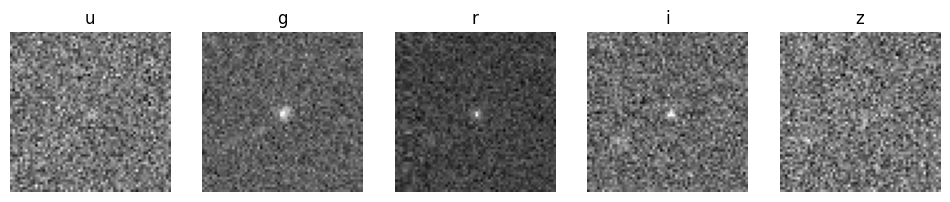

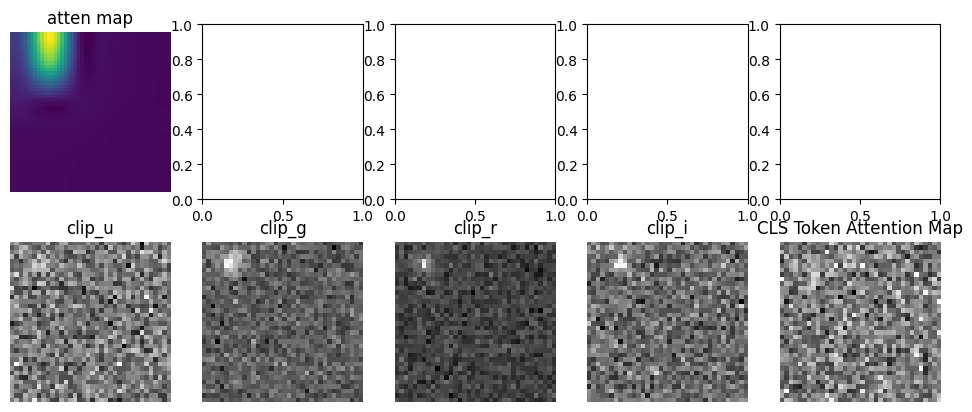

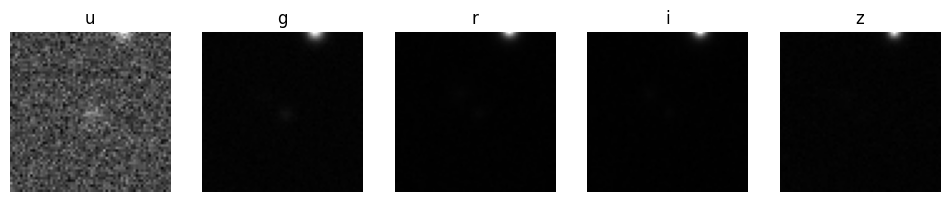

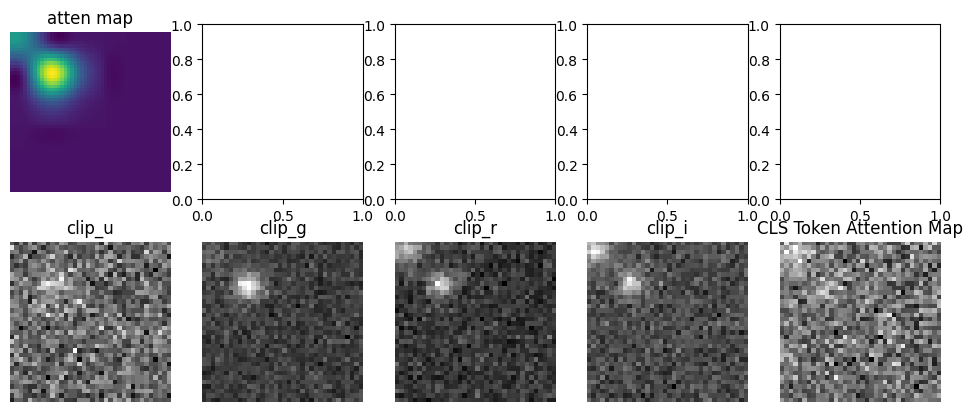

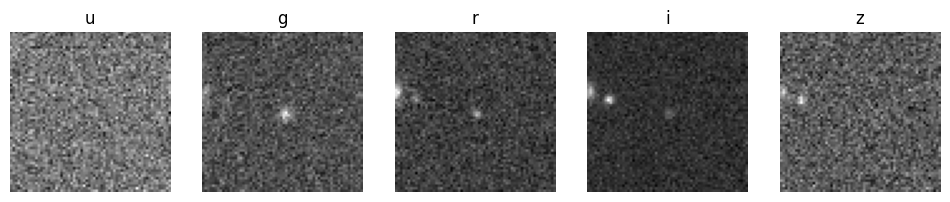

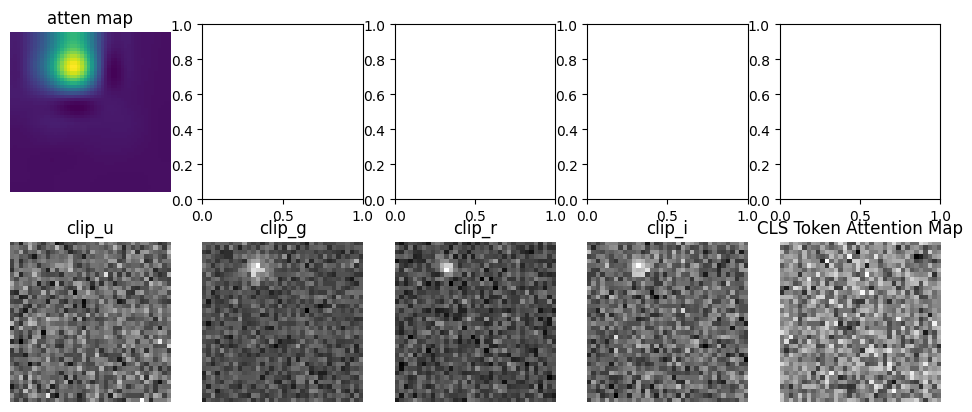

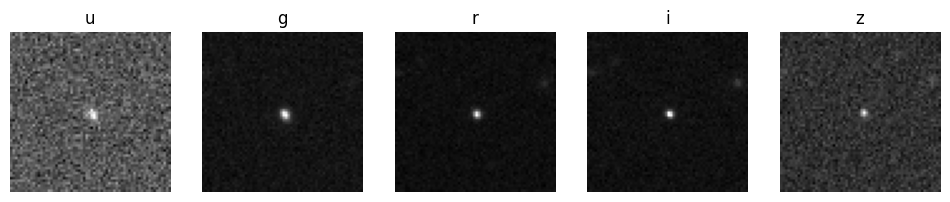

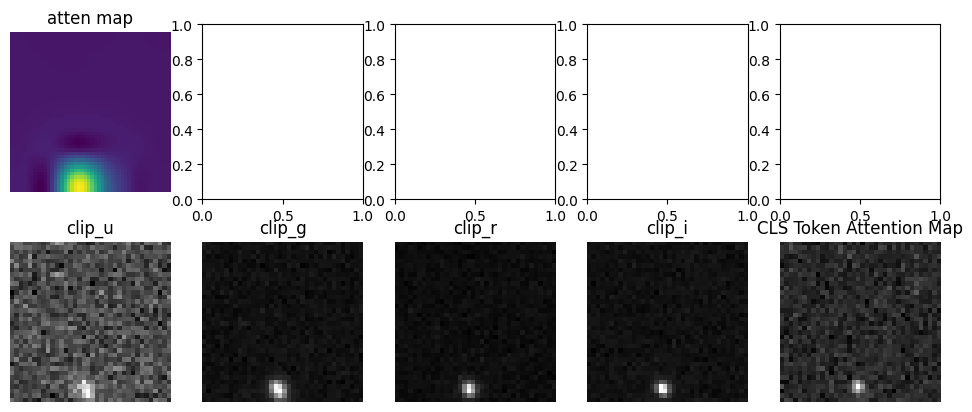

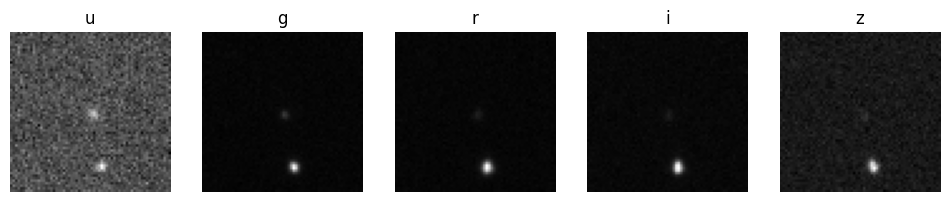

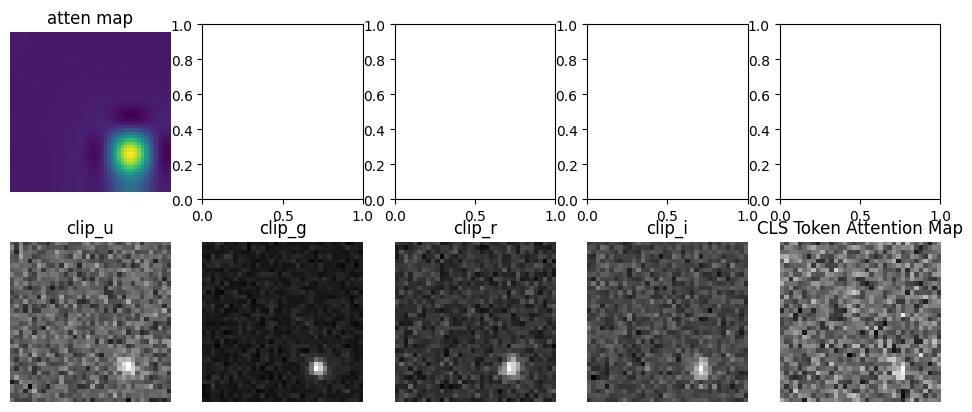

In [10]:
# 使用random随机抽取10张图片
idxs = np.random.randint(len(dset), size=5)
images = dset["image"][idxs]

for image in images:
    trans = transforms.Compose([
        transforms.RandomCrop(36),
        transforms.Normalize(mean=[0.003918, 0.00564221, 0.00870101, 0.01226911, 0.01992336],
                             std=[0.4310049, 0.27417892, 0.38182727, 0.47646362, 1.3710657]),

    ])
    image_t = trans(image)

    fig, axs = plt.subplots(1, 5, figsize=(12, 5))
    bands=['u', 'g', 'r', 'i', 'z']
    for i in range(5):
        axs[i].imshow(image[i], cmap='gray')
        axs[i].axis('off')  # 隐藏坐标轴
        axs[i].set_title(bands[i])

    visualize_attention(model, image_t)